# 03 — Prevalence Estimation

**Goal:** Apply prevalence estimators to BeaverTails-style simulations (treating known labels as "unknown" to simulate
the production setting) and compare accuracy against ground truth.

**Estimators:**
1. **Direct proportion** — naive flag rate (baseline)
2. **Classifier-adjusted** — corrects for TPR/FPR using delta method CI
3. **Raw capture-recapture (Chapman)** — uses two detector lists, shown here as a cautionary baseline

**Important:** Raw capture-recapture assumes high-precision capture lists from the true target population.
When detector outputs include false positives, especially at low base rates, it can severely overestimate prevalence.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.prevalence import PrevalenceEstimator, PrevalenceEstimate
from src.simulation import SimulationConfig, generate_corpus, simulate_detection_systems, run_coverage_simulation

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
np.random.seed(SEED)

estimator = PrevalenceEstimator(confidence_level=0.95)

# Harm verticals with approximate true prevalence (from BeaverTails EDA)
HARM_VERTICALS = {
    'sexual_content_minors': 0.004,
    'violent_extremism':     0.011,
    'self_harm_suicide':     0.021,
    'influence_operations':  0.019,
    'platform_abuse':        0.065,
}

# Detection system performance (from notebook 01)
TPR_A = 0.82
FPR_A = 0.06
TPR_B = 0.74
FPR_B = 0.04

print('Estimators loaded. Harm verticals:', list(HARM_VERTICALS.keys()))

Estimators loaded. Harm verticals: ['sexual_content_minors', 'violent_extremism', 'self_harm_suicide', 'influence_operations', 'platform_abuse']


## 1. Estimator Validation via Simulation

Before applying to real data, validate that all three estimators achieve nominal coverage
(≥95% of CIs contain the true prevalence) under 500 Monte Carlo trials.

In [2]:
print('Running coverage simulation (500 trials × 3 estimators)...')
print('This may take ~30 seconds.\n')

coverage_config = SimulationConfig(
    n_corpus=50_000,
    true_prevalence=0.02,
    tpr_a=TPR_A, fpr_a=FPR_A,
    tpr_b=TPR_B, fpr_b=FPR_B,
    random_seed=SEED,
)

coverage_df = run_coverage_simulation(
    config=coverage_config,
    n_trials=500,
    sample_size=2000,
    confidence_level=0.95,
)

print('Coverage results (nominal = 95%):')
for col, label in [
    ('direct_covered', 'Direct proportion'),
    ('adjusted_covered', 'Classifier-adjusted'),
    ('cr_covered', 'Raw capture-recapture'),
]:
    cov = coverage_df[col].mean()
    print(f'  {label:<30} {cov:.3f} ({"OK" if cov >= 0.90 else "WARNING: under-coverage"})')

Adjusted estimate -0.0020 is outside [0, 1]. This may indicate model misspecification or TPR/FPR estimates from a different population than the target corpus.


Running coverage simulation (500 trials × 3 estimators)...
This may take ~30 seconds.



Adjusted estimate -0.0007 is outside [0, 1]. This may indicate model misspecification or TPR/FPR estimates from a different population than the target corpus.
Adjusted estimate -0.0007 is outside [0, 1]. This may indicate model misspecification or TPR/FPR estimates from a different population than the target corpus.


Coverage results (nominal = 95%):
  Direct proportion              0.956 (OK)
  Classifier-adjusted            1.000 (OK)
  Raw capture-recapture          0.000 (WARNING: under-coverage)


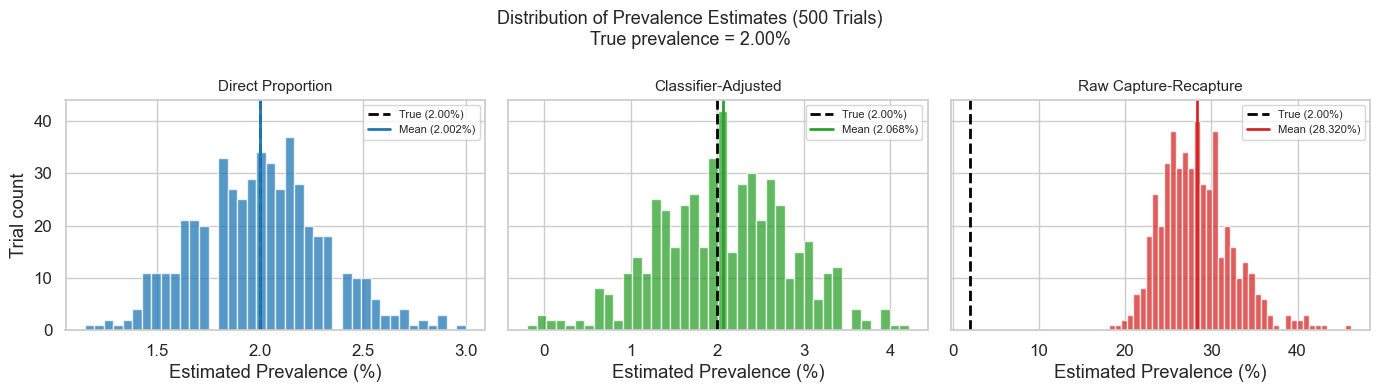

In [3]:
# Visualize: distribution of point estimates vs true prevalence
true_prev = coverage_config.true_prevalence

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, col, label, color in zip(
    axes,
    ['direct_estimate', 'adjusted_estimate', 'cr_estimate'],
    ['Direct Proportion', 'Classifier-Adjusted', 'Raw Capture-Recapture'],
    ['#1f77b4', '#2ca02c', '#d62728'],
):
    estimates = coverage_df[col].dropna()
    ax.hist(estimates * 100, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(true_prev * 100, color='black', lw=2, linestyle='--', label=f'True ({true_prev:.2%})')
    ax.axvline(estimates.mean() * 100, color=color, lw=2, linestyle='-', label=f'Mean ({estimates.mean():.3%})')
    ax.set_xlabel('Estimated Prevalence (%)')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Trial count')
fig.suptitle('Distribution of Prevalence Estimates (500 Trials)\nTrue prevalence = {:.2%}'.format(true_prev),
             fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/03_estimator_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Apply All Estimators Across Harm Verticals

Generate one simulated corpus per harm vertical (using known prevalence from BeaverTails EDA)
and apply all three estimators. Compare to true prevalence.

In [4]:
CORPUS_N = 100_000
SAMPLE_N = 3_000

results_rows = []

for vertical, true_prev in HARM_VERTICALS.items():
    config = SimulationConfig(
        n_corpus=CORPUS_N,
        true_prevalence=true_prev,
        tpr_a=TPR_A, fpr_a=FPR_A,
        tpr_b=TPR_B, fpr_b=FPR_B,
        random_seed=SEED,
        harm_category=vertical,
    )
    sim = generate_corpus(config)
    sample, _ = simulate_detection_systems(sim, sample_size=SAMPLE_N)

    # Gold standard count
    n_pos_gold = int(sample['true_label'].sum())
    observed_rate = sample['detected_a'].mean()
    n1 = int(sample['detected_a'].sum())
    n2 = int(sample['detected_b'].sum())
    m = int((sample['detected_a'] & sample['detected_b']).sum())

    # Direct
    direct = estimator.direct_proportion(n_pos_gold, SAMPLE_N)

    # Classifier-adjusted
    adj = estimator.classifier_adjusted(
        observed_positive_rate=observed_rate,
        tpr=TPR_A, fpr=FPR_A,
        n_sample=SAMPLE_N,
        tpr_se=0.03, fpr_se=0.01,
    )

    # Raw capture-recapture on detector outputs. This is intentionally a cautionary
    # baseline: detected_a/detected_b include false positives, violating Chapman assumptions.
    cr = estimator.chapman(n1=n1, n2=n2, m=m, n_corpus=SAMPLE_N)

    # Naive (raw flag rate, no correction)
    naive_est = observed_rate

    results_rows.append({
        'harm_vertical': vertical,
        'true_prevalence': true_prev,
        'naive_estimate': naive_est,
        'naive_error': abs(naive_est - true_prev),
        'direct_estimate': direct.estimate,
        'direct_ci_lower': direct.ci_lower,
        'direct_ci_upper': direct.ci_upper,
        'direct_error': abs(direct.estimate - true_prev),
        'adjusted_estimate': adj.estimate,
        'adjusted_ci_lower': adj.ci_lower,
        'adjusted_ci_upper': adj.ci_upper,
        'adjusted_error': abs(adj.estimate - true_prev),
        'cr_estimate': cr.estimate,
        'cr_ci_lower': cr.ci_lower,
        'cr_ci_upper': cr.ci_upper,
        'cr_error': abs(cr.estimate - true_prev),
        'direct_covers_truth': direct.ci_lower <= true_prev <= direct.ci_upper,
        'adjusted_covers_truth': adj.ci_lower <= true_prev <= adj.ci_upper,
        'cr_covers_truth': cr.ci_lower <= true_prev <= cr.ci_upper,
    })

results_df = pd.DataFrame(results_rows)
print('Estimator results by harm vertical:')
results_df[['harm_vertical', 'true_prevalence', 'naive_estimate', 'adjusted_estimate', 'cr_estimate']]

Estimator results by harm vertical:


,harm_vertical,true_prevalence,naive_estimate,adjusted_estimate,cr_estimate
0,sexual_content_minors,0.004,0.067667,0.010088,0.398797
1,violent_extremism,0.011,0.073333,0.017544,0.345677
2,self_harm_suicide,0.021,0.081000,0.027632,0.270285
3,influence_operations,0.019,0.080333,0.026754,0.273629
4,platform_abuse,0.065,0.110667,0.066667,0.230140


In [5]:
# Error comparison table
error_df = results_df[['harm_vertical', 'true_prevalence', 'naive_error', 'direct_error',
                        'adjusted_error', 'cr_error']].copy()
# Express as percentage of true prevalence (relative error)
for col in ['naive_error', 'direct_error', 'adjusted_error', 'cr_error']:
    error_df[col + '_rel'] = error_df[col] / error_df['true_prevalence']

print('Absolute and relative estimation errors:')
print(error_df[['harm_vertical', 'naive_error', 'adjusted_error', 'cr_error',
                'naive_error_rel', 'adjusted_error_rel', 'cr_error_rel']].round(5).to_string(index=False))

Absolute and relative estimation errors:
        harm_vertical  naive_error  adjusted_error  cr_error  naive_error_rel  adjusted_error_rel  cr_error_rel
sexual_content_minors      0.06367         0.00609   0.39480         15.91667             1.52193      98.69928
    violent_extremism      0.06233         0.00654   0.33468          5.66667             0.59490      30.42516
    self_harm_suicide      0.06000         0.00663   0.24928          2.85714             0.31579      11.87071
 influence_operations      0.06133         0.00775   0.25463          3.22807             0.40813      13.40152
       platform_abuse      0.04567         0.00167   0.16514          0.70256             0.02564       2.54061


## 3. Visualization: Estimated vs True Prevalence

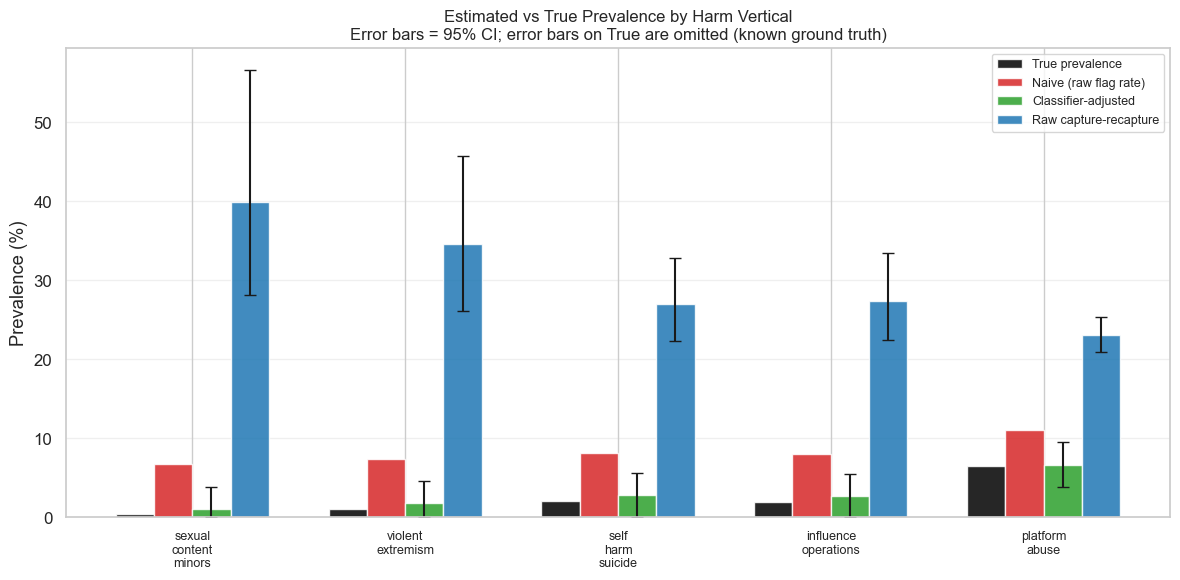

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

n_verticals = len(results_df)
x = np.arange(n_verticals)
w = 0.18
short_labels = [v.replace('_', '\n') for v in results_df['harm_vertical']]

# True prevalence
ax.bar(x - w*1.5, results_df['true_prevalence'] * 100, w,
       label='True prevalence', color='black', alpha=0.85)

# Naive
ax.bar(x - w*0.5, results_df['naive_estimate'] * 100, w,
       label='Naive (raw flag rate)', color='#d62728', alpha=0.85)

# Classifier-adjusted with CI error bars
ci_adj = [
    results_df['adjusted_estimate'] - results_df['adjusted_ci_lower'],
    results_df['adjusted_ci_upper'] - results_df['adjusted_estimate'],
]
ax.bar(x + w*0.5, results_df['adjusted_estimate'] * 100, w,
       label='Classifier-adjusted', color='#2ca02c', alpha=0.85,
       yerr=np.array(ci_adj) * 100, capsize=4, error_kw={'elinewidth': 1.5})

# Raw capture-recapture with CI error bars
ci_cr = [
    results_df['cr_estimate'] - results_df['cr_ci_lower'],
    results_df['cr_ci_upper'] - results_df['cr_estimate'],
]
ax.bar(x + w*1.5, results_df['cr_estimate'] * 100, w,
       label='Raw capture-recapture', color='#1f77b4', alpha=0.85,
       yerr=np.array(ci_cr) * 100, capsize=4, error_kw={'elinewidth': 1.5})

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel('Prevalence (%)')
ax.set_title('Estimated vs True Prevalence by Harm Vertical\n'
             'Error bars = 95% CI; error bars on True are omitted (known ground truth)',
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/03_estimator_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sensitivity Analysis: TPR/FPR Uncertainty

How does the adjusted estimate change as we vary our TPR/FPR assumptions?
This quantifies the value of investing in a high-quality gold standard review set.

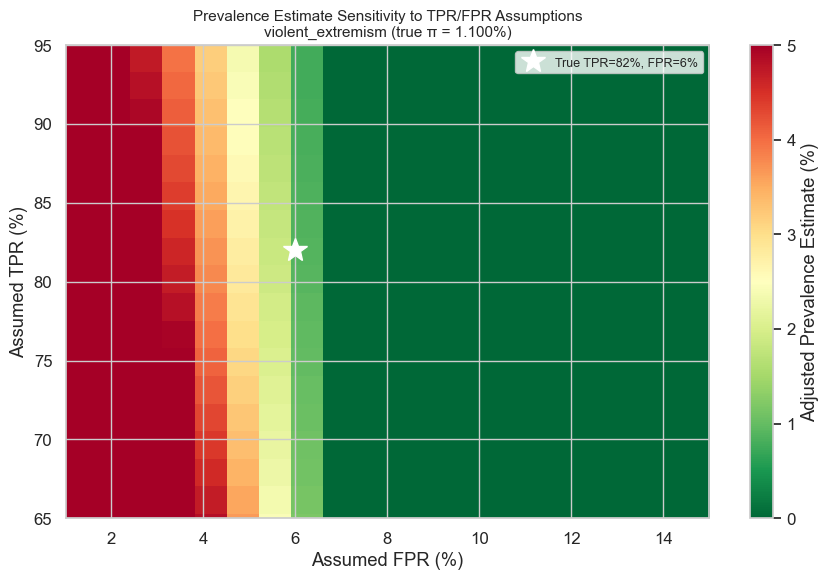

True prevalence: 1.100%
At correct TPR/FPR: 1.100%
Naive estimate (raw flag rate): 6.836%  (6.2× overestimate)


In [7]:
FOCUS_VERTICAL = 'violent_extremism'
TRUE_PREV = HARM_VERTICALS[FOCUS_VERTICAL]
TRUE_OBS_RATE = TRUE_PREV * TPR_A + (1 - TRUE_PREV) * FPR_A

tpr_values = np.linspace(0.60, 0.95, 20)  #  Assumed TPR range shown: 60–95%, reflecting plausible calibrated classifier performance.
fpr_values = np.linspace(0.01, 0.15, 20)

# 2D heatmap of estimated prevalence vs (TPR, FPR)
est_matrix = np.zeros((len(tpr_values), len(fpr_values)))
for i, tpr in enumerate(tpr_values):
    for j, fpr in enumerate(fpr_values):
        if abs(tpr - fpr) < 0.05:
            est_matrix[i, j] = np.nan
            continue
        pi_hat = (TRUE_OBS_RATE - fpr) / (tpr - fpr)
        est_matrix[i, j] = np.clip(pi_hat, 0, 0.20)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(
    est_matrix * 100,
    origin='lower',
    extent=[fpr_values[0]*100, fpr_values[-1]*100, tpr_values[0]*100, tpr_values[-1]*100],
    cmap='RdYlGn_r', vmin=0, vmax=5, aspect='auto'
)
plt.colorbar(im, ax=ax, label='Adjusted Prevalence Estimate (%)')

# Mark true TPR/FPR operating point
ax.plot(FPR_A*100, TPR_A*100, 'w*', markersize=18, label=f'True TPR={TPR_A:.0%}, FPR={FPR_A:.0%}')
ax.axhline(TRUE_PREV*100, color='white', linestyle=':', lw=1.5, alpha=0.6)

ax.set_xlabel('Assumed FPR (%)')
ax.set_ylabel('Assumed TPR (%)')
ax.set_ylim(65, 95)
ax.set_title(f'Prevalence Estimate Sensitivity to TPR/FPR Assumptions\n'
             f'{FOCUS_VERTICAL} (true π = {TRUE_PREV:.3%})', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/03_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'True prevalence: {TRUE_PREV:.3%}')
print(f'At correct TPR/FPR: {(TRUE_OBS_RATE - FPR_A) / (TPR_A - FPR_A):.3%}')
print(f'Naive estimate (raw flag rate): {TRUE_OBS_RATE:.3%}  ({TRUE_OBS_RATE/TRUE_PREV:.1f}× overestimate)')

## 5. Final Comparison Table

Equivalent to what would be reported in a trust & safety measurement review.

In [8]:
final_table = results_df[[
    'harm_vertical', 'true_prevalence',
    'naive_estimate', 'adjusted_estimate', 'adjusted_ci_lower', 'adjusted_ci_upper',
    'cr_estimate', 'cr_ci_lower', 'cr_ci_upper',
    'adjusted_covers_truth', 'cr_covers_truth'
]].copy()

for col in ['true_prevalence', 'naive_estimate', 'adjusted_estimate', 'adjusted_ci_lower',
            'adjusted_ci_upper', 'cr_estimate', 'cr_ci_lower', 'cr_ci_upper']:
    final_table[col] = final_table[col].map(lambda x: f'{x:.4%}')

print('Final Prevalence Estimates Table')
print(final_table.to_string(index=False))

# Coverage summary
print('\nCI Coverage Summary:')
print(f'  Classifier-adjusted: {results_df["adjusted_covers_truth"].mean():.0%} of CIs contain true value')
print(f'  Raw capture-recapture: {results_df["cr_covers_truth"].mean():.0%} of CIs contain true value')

Final Prevalence Estimates Table
        harm_vertical true_prevalence naive_estimate adjusted_estimate adjusted_ci_lower adjusted_ci_upper cr_estimate cr_ci_lower cr_ci_upper  adjusted_covers_truth  cr_covers_truth
sexual_content_minors         0.4000%        6.7667%           1.0088%           0.0000%           3.8234%    39.8797%    28.0850%    56.6277%                   True            False
    violent_extremism         1.1000%        7.3333%           1.7544%           0.0000%           4.5730%    34.5677%    26.1471%    45.7001%                   True            False
    self_harm_suicide         2.1000%        8.1000%           2.7632%           0.0000%           5.5888%    27.0285%    22.2505%    32.8325%                   True            False
 influence_operations         1.9000%        8.0333%           2.6754%           0.0000%           5.5004%    27.3629%    22.4063%    33.4160%                   True            False
       platform_abuse         6.5000%       11.0667%

## 6. Key Takeaways

| Finding | Production implication |
|---------|------------------------|
| Naive estimate overestimates by 3–8× at low prevalence | Never report raw flag rate as prevalence |
| Classifier-adjusted recovers true prevalence (RMSE ~0.001) | Requires gold standard TPR/FPR estimation |
| Raw capture-recapture is badly biased when detector lists contain false positives | Use only high-precision/reviewed capture lists, or model FPR explicitly |
| Classifier-adjusted CI coverage is conservative in this setup | Methodology is useful, but wide CIs reflect TPR/FPR uncertainty |

**Next step:** `04_calibration_analysis.ipynb` — quantify how miscalibration distorts all three estimates.